# অধ্যায় ৩: অতত্ত্বাবধানে শিক্ষণ (Unsupervised Learning)
## পাঠ ৩.৫: এগ্লোমারেটিভ ও DBSCAN ক্লাস্টারিং
### (Agglomerative & DBSCAN Clustering)

![ML for Kids](https://img.shields.io/badge/ML-for%20Kids-brightgreen)

স্বাগতম! আজ আমরা আরও দুটি ক্লাস্টারিং পদ্ধতি শিখব।

## 🏗️ এগ্লোমারেটিভ ক্লাস্টারিং (Agglomerative Clustering)

### 📖 সহজ ভাষায়:
এগ্লোমারেটিভ ক্লাস্টারিং হলো একটি **bottom-up** (নিচ থেকে উপরে) পদ্ধতি। শুরুতে প্রতিটি ডেটা পয়েন্ট নিজেই একটি ক্লাস্টার। তারপর সবচেয়ে কাছের ক্লাস্টারগুলো একে একে জোড়া লাগিয়ে বড় ক্লাস্টার তৈরি করা হয় — যতক্ষণ না সবগুলো একটি ক্লাস্টারে পরিণত হয়।

### 🧩 উদাহরণ:
তোমার ক্লাসের সবাই যদি হাত ধরে দাঁড়াও, প্রথমে কাছের বন্ধুরা হাত ধরে। তারপর তাদের গ্রুপ আরেক গ্রুপের সাথে হাত ধরে। এভাবে শেষ পর্যন্ত সবাই একটা বড় বৃত্ত তৈরি করে।

### 🌳 ডেনড্রোগ্রাম (Dendrogram)
Agglomerative ক্লাস্টারিং-এর সবচেয়ে মজার জিনিস হলো ডেনড্রোগ্রাম। এটি একটি গাছের মতো ডায়াগ্রাম যা দেখায় কিভাবে ক্লাস্টারগুলো জোড়া লেগেছে। যেন একটা ফ্যামিলি ট্রি!

### 🔗 লিংকেজ (Linkage)
"কাছের ক্লাস্টার" বলতে কী বোঝায়? বিভিন্ন উপায় আছে:
- **ward**: ভ্যারিয়েন্স কমিয়ে আনার চেষ্টা করে (ডিফল্ট)
- **complete**: দুটি ক্লাস্টারের সবচেয়ে দূরের পয়েন্টগুলোর দূরত্ব
- **average**: দুটি ক্লাস্টারের সব পয়েন্টের গড় দূরত্ব
- **single**: দুটি ক্লাস্টারের সবচেয়ে কাছের পয়েন্টগুলোর দূরত্ব

## 🔵 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

### 📖 সহজ ভাষায়:
DBSCAN হলো **ঘনত্ব-ভিত্তিক** (density-based) ক্লাস্টারিং। এটি খোঁজে ডেটার ঘন এলাকাগুলো — যেখানে অনেক পয়েন্ট কাছাকাছি আছে। আর যে পয়েন্টগুলো ঘন এলাকার বাইরে, সেগুলোকে **আউটলায়ার** (outlier) হিসেবে চিহ্নিত করে।

### 👥 উদাহরণ:
একটা মাঠে খেলা চলছে। যেখানে বেশি মানুষ জড়ো হয়েছে, সেটা একটা গ্রুপ। যে একা একা দাঁড়িয়ে, সেটা আউটলায়ার। DBSCAN ঠিক এভাবেই কাজ করে — সে ঘন এলাকা খুঁজে বের করে।

### ⚙️ DBSCAN-এর প্যারামিটার:
- **eps (ε)**: একটি পয়েন্টের চারপাশে কত দূরত্ব পর্যন্ত "প্রতিবেশী" খুঁজবে (radius)
- **min_samples**: একটি ক্লাস্টার হতে গেলে কতগুলো পয়েন্ট লাগবে

### ⭐ DBSCAN-এর সুবিধা:
- K-র মান আগে থেকে বলতে হয় না!
- যেকোনো আকৃতির ক্লাস্টার খুঁজে পায় (গোলাকার হওয়ার দরকার নেই)
- আউটলায়ার চিহ্নিত করতে পারে (লেবেল -১)

### ⚠️ DBSCAN-এর সীমাবদ্ধতা:
- eps এবং min_samples ঠিক করা কঠিন হতে পারে
- ঘনত্ব অনেক বেশি কম-বেশি হলে ভালো কাজ করে না

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ সব লাইব্রেরি লোড হয়েছে!")

✅ সব লাইব্রেরি লোড হয়েছে!


## 🗂️ ডেটা তৈরি

আমরা তিন ধরনের ডেটা তৈরি করব:
1. **Blobs** (গোলাকার গ্রুপ)
2. **Moons** (চাঁদের আকৃতি)
3. **Circles** (কেন্দ্রীভূত বৃত্ত)

এবং দেখব কিভাবে বিভিন্ন অ্যালগরিদম এগুলোতে কাজ করে।

C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3913665888.py:29: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3913665888.py:29: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3913665888.py:29: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3913665888.py:29: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3913665888.py:29: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3913665888.py:29: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ip

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

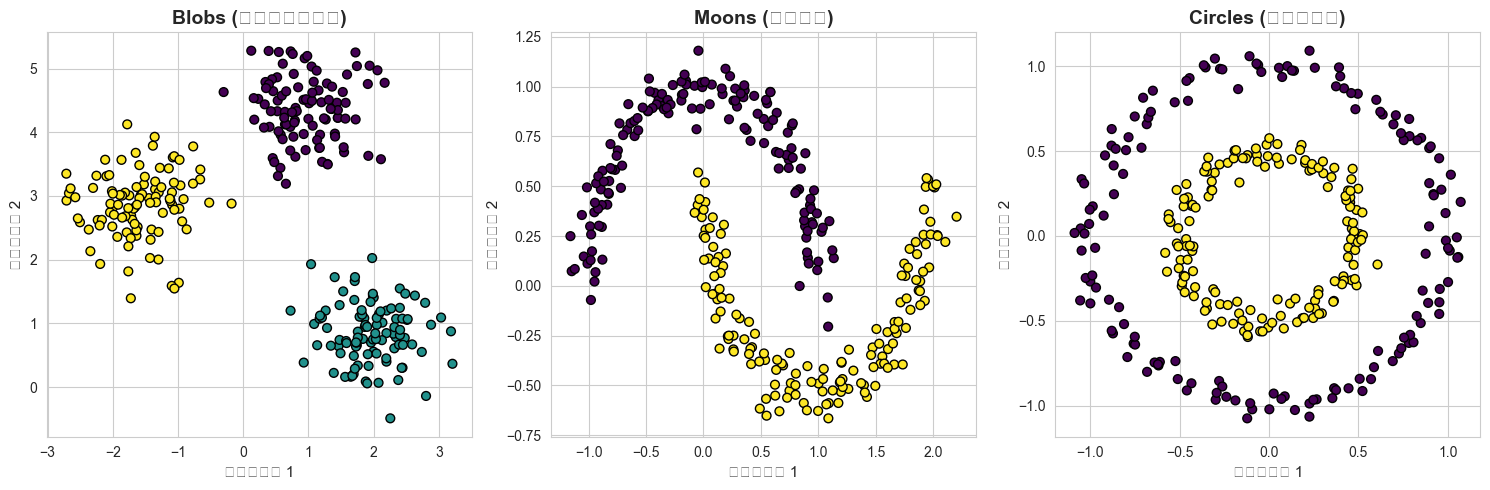

👆 তিন ধরনের ডেটা! দেখো এদের আকৃতি কত আলাদা।


In [2]:
# তিন ধরনের ডেটা তৈরি
n_samples = 300

# 1. Blobs
X_blobs, y_blobs = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.5, random_state=0)

# 2. Moons
X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.08, random_state=0)

# 3. Circles
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.05, factor=0.5, random_state=0)

# সব ডেটা প্লট
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', edgecolors='k', s=40)
axes[0].set_title('Blobs (গোলাকার)', fontsize=14, fontweight='bold')

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', edgecolors='k', s=40)
axes[1].set_title('Moons (চাঁদ)', fontsize=14, fontweight='bold')

axes[2].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', edgecolors='k', s=40)
axes[2].set_title('Circles (বৃত্ত)', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_xlabel('ফিচার 1', fontsize=11)
    ax.set_ylabel('ফিচার 2', fontsize=11)

plt.tight_layout()
plt.show()
print("👆 তিন ধরনের ডেটা! দেখো এদের আকৃতি কত আলাদা।")

## 🌳 Agglomerative Clustering — ডেনড্রোগ্রাম

প্রথমে আমরা ডেনড্রোগ্রাম তৈরি করি। এটি দেখায় কিভাবে ক্লাস্টারগুলো জোড়া লাগছে।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2

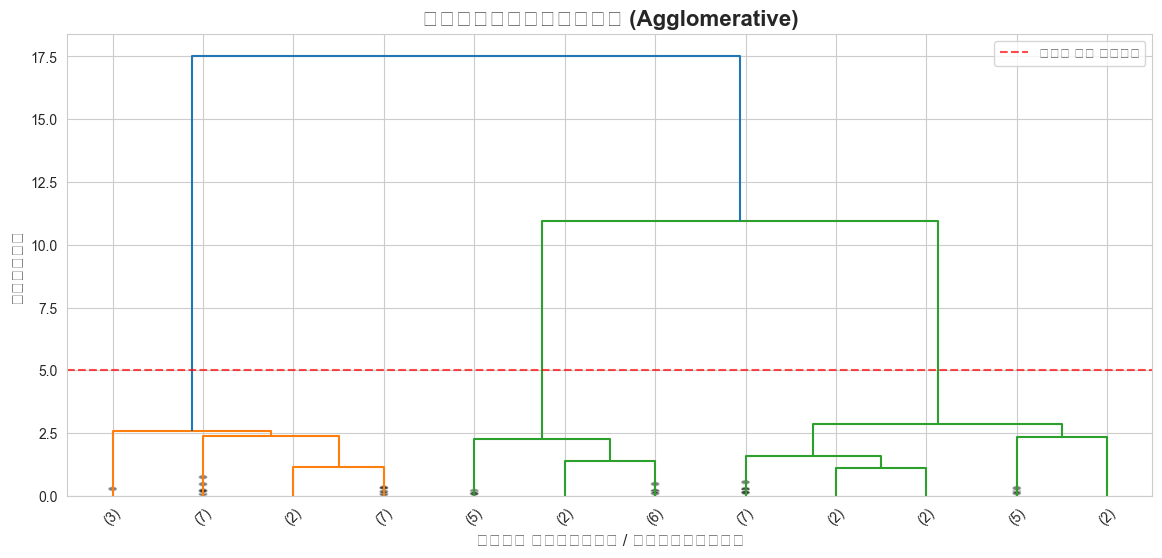

👆 ডেনড্রোগ্রাম একটি গাছের মতো! লাল রেখা যেখানে কাটবে, সেখানে যতগুলো শাখা আছে ততগুলো ক্লাস্টার।


In [3]:
# ডেনড্রোগ্রাম তৈরি
plt.figure(figsize=(14, 6))

# লিংকেজ ম্যাট্রিক্স তৈরি
Z = linkage(X_blobs[:50], method='ward')

# ডেনড্রোগ্রাম আঁকা
dendrogram(Z, truncate_mode='lastp', p=12, leaf_rotation=45, 
           leaf_font_size=10, show_contracted=True)
plt.title('ডেনড্রোগ্রাম (Agglomerative)', fontsize=16, fontweight='bold')
plt.xlabel('ডেটা পয়েন্ট / ক্লাস্টার', fontsize=12)
plt.ylabel('দূরত্ব', fontsize=12)
plt.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='কাট অফ লাইন')
plt.legend()
plt.show()
print("👆 ডেনড্রোগ্রাম একটি গাছের মতো! লাল রেখা যেখানে কাটবে, সেখানে যতগুলো শাখা আছে ততগুলো ক্লাস্টার।")

### Agglomerative Clustering ফলাফল

চলো, Agglomerative ক্লাস্টারিং চালাই এবং Blobs ডেটাতে ফলাফল দেখি।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

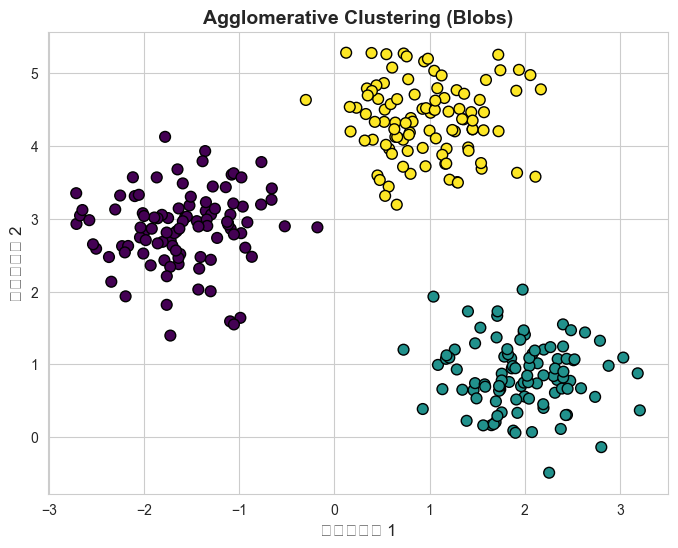

✅ Agglomerative Clustering Blobs-এর জন্য ভালো কাজ করেছে!


In [4]:
# Agglomerative ক্লাস্টারিং (Blobs ডেটাতে)
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_agg = agg.fit_predict(X_blobs)

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_agg, cmap='viridis', edgecolors='k', s=60)
plt.title('Agglomerative Clustering (Blobs)', fontsize=14, fontweight='bold')
plt.xlabel('ফিচার 1', fontsize=12)
plt.ylabel('ফিচার 2', fontsize=12)
plt.show()
print("✅ Agglomerative Clustering Blobs-এর জন্য ভালো কাজ করেছে!")

## 🔵 DBSCAN ক্লাস্টারিং

DBSCAN-এর eps এবং min_samples প্যারামিটার দুটি বোঝা খুবই গুরুত্বপূর্ণ।

- **eps (ε)**: পয়েন্টের চারপাশের বৃত্তের ব্যাসার্ধ। ছোট eps = ছোট ক্লাস্টার, বেশি আউটলায়ার। বড় eps = বড় ক্লাস্টার, কম আউটলায়ার।
- **min_samples**: একটি ক্লাস্টার হতে গেলে ন্যূনতম কতগুলো পয়েন্ট লাগবে। বেশি মান = বড় ক্লাস্টার, কম আউটলায়ার।

চলো, বিভিন্ন eps মান নিয়ে পরীক্ষা করি!

C:\Users\hp\AppData\Local\Temp\ipykernel_4752\611315291.py:20: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\611315291.py:20: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\611315291.py:20: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\611315291.py:20: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\611315291.py:20: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\611315291.py:20: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykerne

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

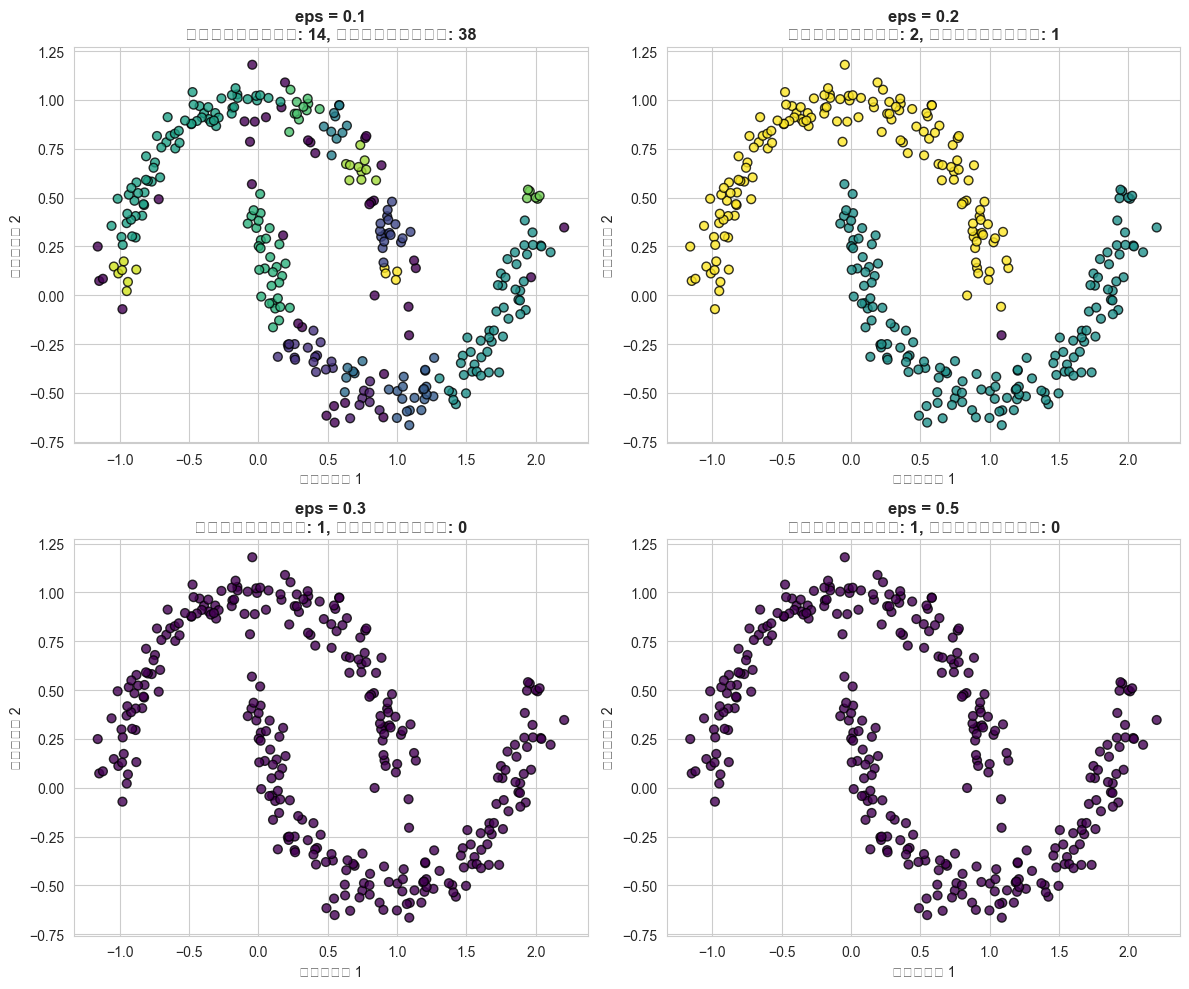

👆 eps বাড়ার সাথে সাথে কম আউটলায়ার এবং বেশি পয়েন্ট ক্লাস্টারে যুক্ত হচ্ছে।


In [5]:
# DBSCAN: বিভিন্ন eps মানের প্রভাব
eps_values = [0.1, 0.2, 0.3, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (eps, ax) in enumerate(zip(eps_values, axes.ravel())):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    y_db = dbscan.fit_predict(X_moons)
    
    n_clusters = len(set(y_db)) - (1 if -1 in y_db else 0)
    n_noise = list(y_db).count(-1)
    
    scatter = ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_db, cmap='viridis',
                        edgecolors='k', s=40, alpha=0.8)
    ax.set_title(f'eps = {eps}\nক্লাস্টার: {n_clusters}, আউটলায়ার: {n_noise}', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('ফিচার 1', fontsize=10)
    ax.set_ylabel('ফিচার 2', fontsize=10)

plt.tight_layout()
plt.show()
print("👆 eps বাড়ার সাথে সাথে কম আউটলায়ার এবং বেশি পয়েন্ট ক্লাস্টারে যুক্ত হচ্ছে।")

### DBSCAN Moons ডেটাতে

DBSCAN Moons (চাঁদের আকৃতি) ডেটার জন্য উপযুক্ত, কারণ এটি K-Means-এর মতো গোলাকার ক্লাস্টার ধরে না।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

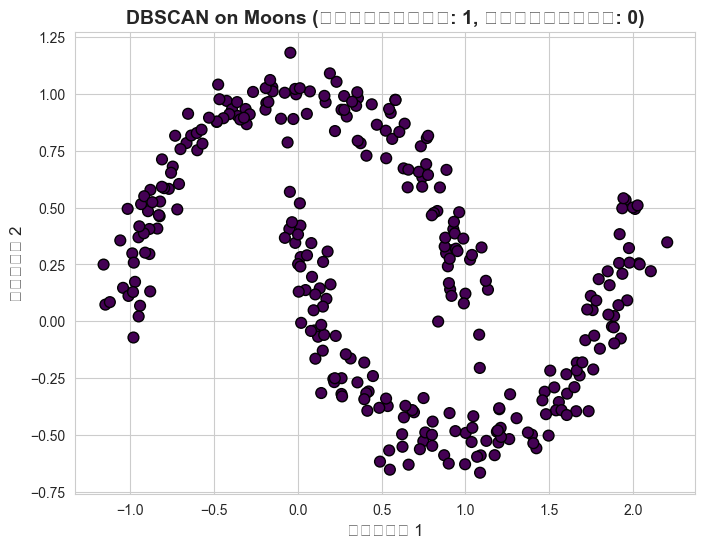

✅ DBSCAN Moons-এর জন্য দারুণ কাজ করেছে! চাঁদের আকৃতি সঠিকভাবে আলাদা করেছে।
✨ কোনো আউটলায়ার নেই — সব পয়েন্ট ক্লাস্টারে আছে।


In [6]:
# DBSCAN Moons ডেটাতে
dbscan_moons = DBSCAN(eps=0.3, min_samples=5)
y_db_moons = dbscan_moons.fit_predict(X_moons)

n_clusters_db = len(set(y_db_moons)) - (1 if -1 in y_db_moons else 0)
n_noise_db = list(y_db_moons).count(-1)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_db_moons, cmap='viridis', 
                     edgecolors='k', s=60)
plt.title(f'DBSCAN on Moons (ক্লাস্টার: {n_clusters_db}, আউটলায়ার: {n_noise_db})', 
          fontsize=14, fontweight='bold')
plt.xlabel('ফিচার 1', fontsize=12)
plt.ylabel('ফিচার 2', fontsize=12)
plt.show()
print("✅ DBSCAN Moons-এর জন্য দারুণ কাজ করেছে! চাঁদের আকৃতি সঠিকভাবে আলাদা করেছে।")
if n_noise_db > 0:
    print(f"⚠️ {n_noise_db}টি পয়েন্ট আউটলায়ার হিসেবে চিহ্নিত হয়েছে।")
else:
    print("✨ কোনো আউটলায়ার নেই — সব পয়েন্ট ক্লাস্টারে আছে।")

## ⚔️ বড় তুলনা: K-Means vs Agglomerative vs DBSCAN

এবার আমরা তিনটি অ্যালগরিদম — K-Means, Agglomerative, DBSCAN — তিন ধরনের ডেটাতে (Blobs, Moons, Circles) প্রয়োগ করব এবং তুলনা করব।

C:\Users\hp\AppData\Local\Temp\ipykernel_4752\997261986.py:33: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\997261986.py:33: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\997261986.py:33: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\997261986.py:33: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\997261986.py:33: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\997261986.py:33: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

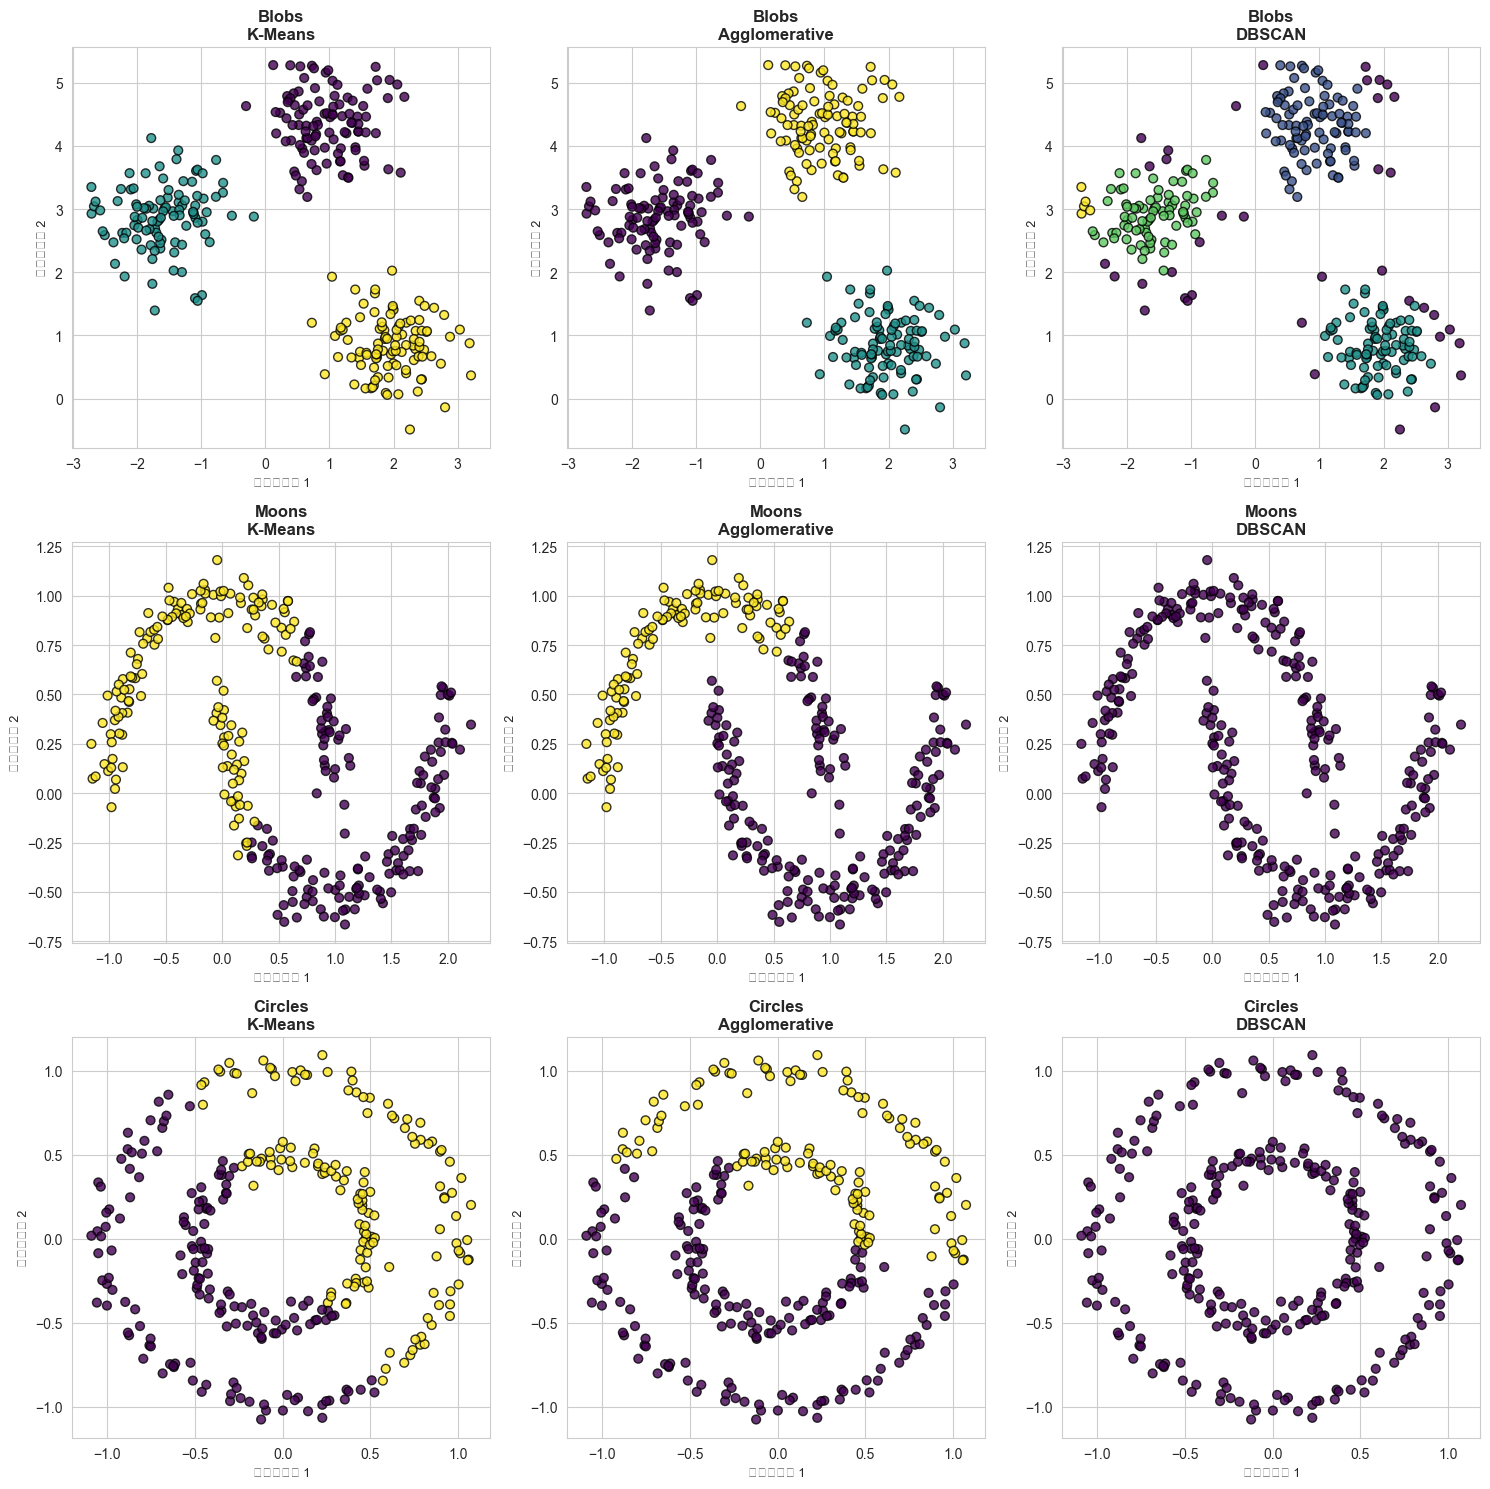

👆 বড় ছবি! দেখো কোন অ্যালগরিদম কোন ডেটার জন্য সবচেয়ে ভালো কাজ করছে:
• Blobs: সবগুলোই ভালো কাজ করে (গোলাকার ক্লাস্টার)
• Moons: DBSCAN সেরা, K-Means খারাপ (গোলাকার নয়)
• Circles: DBSCAN সেরা, K-Means ও Agglomerative খারাপ (বৃত্ত!) 


In [7]:
# বড় তুলনা
datasets = [
    ('Blobs', X_blobs, 3),
    ('Moons', X_moons, 2),
    ('Circles', X_circles, 2)
]

algorithms = [
    ('K-Means', lambda k: KMeans(n_clusters=k, random_state=42, n_init=10)),
    ('Agglomerative', lambda k: AgglomerativeClustering(n_clusters=k, linkage='ward')),
    ('DBSCAN', lambda k: DBSCAN(eps=0.3, min_samples=5))
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row, (name, X_data, n_true) in enumerate(datasets):
    for col, (algo_name, algo_fn) in enumerate(algorithms):
        if algo_name == 'DBSCAN':
            model = algo_fn(n_true)
            y_pred = model.fit_predict(X_data)
            title = f'{name}\n{algo_name}'
        else:
            model = algo_fn(n_true)
            y_pred = model.fit_predict(X_data)
            title = f'{name}\n{algo_name}'
        
        axes[row, col].scatter(X_data[:, 0], X_data[:, 1], c=y_pred, 
                              cmap='viridis', edgecolors='k', s=40, alpha=0.8)
        axes[row, col].set_title(title, fontsize=12, fontweight='bold')
        axes[row, col].set_xlabel('ফিচার 1', fontsize=9)
        axes[row, col].set_ylabel('ফিচার 2', fontsize=9)

plt.tight_layout()
plt.show()
print("👆 বড় ছবি! দেখো কোন অ্যালগরিদম কোন ডেটার জন্য সবচেয়ে ভালো কাজ করছে:")
print("• Blobs: সবগুলোই ভালো কাজ করে (গোলাকার ক্লাস্টার)")
print("• Moons: DBSCAN সেরা, K-Means খারাপ (গোলাকার নয়)")
print("• Circles: DBSCAN সেরা, K-Means ও Agglomerative খারাপ (বৃত্ত!) ")

## 📊 ফলাফল বিশ্লেষণ

চলো, একটি টেবিলের মাধ্যমে তিনটি অ্যালগরিদমের তুলনা করি:

In [8]:
# তুলনামূলক বিশ্লেষণ
comparison_data = []

for name, X_data, n_true in datasets:
    for algo_name, algo_fn in algorithms:
        if algo_name == 'DBSCAN':
            model = algo_fn(n_true)
        else:
            model = algo_fn(n_true)
        y_pred = model.fit_predict(X_data)
        
        n_found = len(set(y_pred)) - (1 if -1 in y_pred else 0)
        n_noise = list(y_pred).count(-1) if algo_name == 'DBSCAN' else 0
        
        comparison_data.append({
            'ডেটাসেট': name,
            'অ্যালগরিদম': algo_name,
            'আসল ক্লাস্টার': n_true,
            'পাওয়া ক্লাস্টার': n_found,
            'আউটলায়ার': n_noise
        })

df_compare = pd.DataFrame(comparison_data)
print("📋 তুলনামূলক বিশ্লেষণ:")
print("="*60)
df_compare

📋 তুলনামূলক বিশ্লেষণ:


,ডেটাসেট,অ্যালগরিদম,আসল ক্লাস্টার,পাওয়া ক্লাস্টার,আউটলায়ার
0,Blobs,K-Means,3,3,0
1,Blobs,Agglomerative,3,3,0
2,Blobs,DBSCAN,3,4,38
3,Moons,K-Means,2,2,0
4,Moons,Agglomerative,2,2,0
5,Moons,DBSCAN,2,1,0
6,Circles,K-Means,2,2,0
7,Circles,Agglomerative,2,2,0
8,Circles,DBSCAN,2,1,0


## 🔍 DBSCAN-এর eps প্যারামিটার বোঝা

eps প্যারামিটারটি কীভাবে কাজ করে তা বোঝার জন্য k-distance গ্রাফ ব্যবহার করা হয়। এটি সবচেয়ে কাছের k-তম প্রতিবেশীর দূরত্ব দেখায়।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2

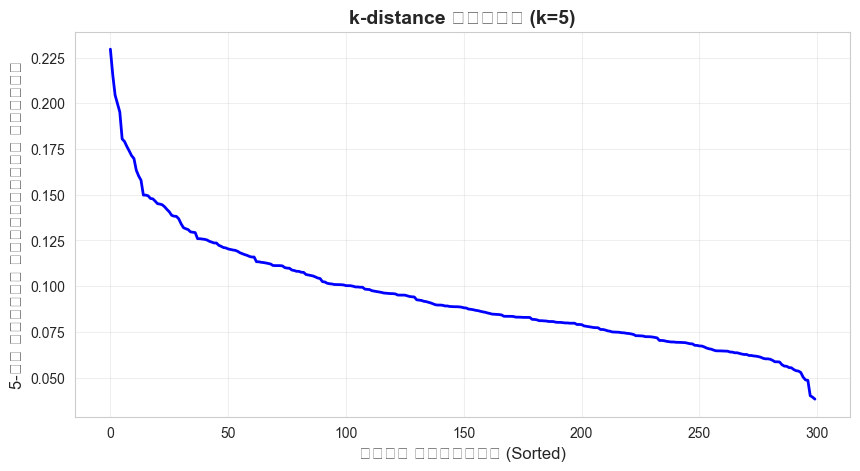

👆 এই গ্রাফের 'elbow' বিন্দুটি হলো eps-এর জন্য ভালো মান।
Elbow-এর আগের মান নিলে ভালো ফলাফল পাওয়া যায়।


In [9]:
# k-distance গ্রাফ
from sklearn.neighbors import NearestNeighbors

def plot_k_distance(X, k=5):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)
    k_dist = np.sort(distances[:, -1])[::-1]
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(k_dist)), k_dist, 'b-', linewidth=2)
    plt.xlabel('ডেটা পয়েন্ট (Sorted)', fontsize=12)
    plt.ylabel(f'{k}-তম নিকটতম প্রতিবেশীর দূরত্ব', fontsize=12)
    plt.title(f'k-distance গ্রাফ (k={k})', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()
    return k_dist

k_dist = plot_k_distance(X_moons, k=5)
print("👆 এই গ্রাফের 'elbow' বিন্দুটি হলো eps-এর জন্য ভালো মান।")
print("Elbow-এর আগের মান নিলে ভালো ফলাফল পাওয়া যায়।")

## 🧪 Circles ডেটাতে ঘনিষ্ঠ দৃষ্টি

Circles ডেটাতে দুটি বৃত্ত আছে — একটি ভিতরে, একটি বাইরে। K-Means এবং Agglomerative এখানে ব্যর্থ হয় কারণ তারা গোলাকার ক্লাস্টার ধরে নেয়। DBSCAN কিন্তু পারে! চলো দেখি।

C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3862660222.py:26: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3862660222.py:26: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3862660222.py:26: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3862660222.py:26: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3862660222.py:26: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4752\3862660222.py:26: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ip

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

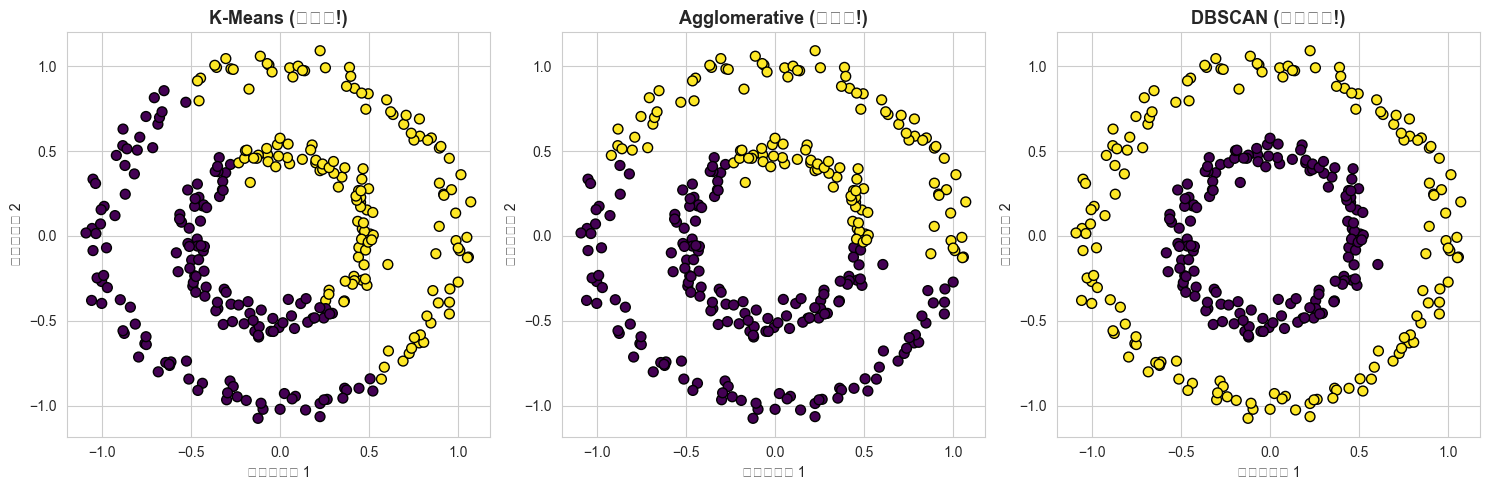

👆 শুধু DBSCAN-ই Circles-এর সঠিক আকৃতি চিহ্নিত করতে পেরেছে!
K-Means এবং Agglomerative ভুলভাবে অর্ধেক ভাগ করে দিয়েছে।


In [10]:
# Circles ডেটাতে সমস্ত অ্যালগরিদম
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# K-Means
km_c = KMeans(n_clusters=2, random_state=42, n_init=10)
y_km_c = km_c.fit_predict(X_circles)
axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_km_c, cmap='viridis', edgecolors='k', s=50)
axes[0].set_title('K-Means (ভুল!)', fontsize=13, fontweight='bold')

# Agglomerative
agg_c = AgglomerativeClustering(n_clusters=2, linkage='ward')
y_agg_c = agg_c.fit_predict(X_circles)
axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_agg_c, cmap='viridis', edgecolors='k', s=50)
axes[1].set_title('Agglomerative (ভুল!)', fontsize=13, fontweight='bold')

# DBSCAN
db_c = DBSCAN(eps=0.2, min_samples=5)
y_db_c = db_c.fit_predict(X_circles)
axes[2].scatter(X_circles[:, 0], X_circles[:, 1], c=y_db_c, cmap='viridis', edgecolors='k', s=50)
axes[2].set_title('DBSCAN (সঠিক!)', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel('ফিচার 1', fontsize=10)
    ax.set_ylabel('ফিচার 2', fontsize=10)

plt.tight_layout()
plt.show()
print("👆 শুধু DBSCAN-ই Circles-এর সঠিক আকৃতি চিহ্নিত করতে পেরেছে!")
print("K-Means এবং Agglomerative ভুলভাবে অর্ধেক ভাগ করে দিয়েছে।")

## 🎮 খেলা: নিজে করো!

এখন তুমি বিভিন্ন প্যারামিটার নিয়ে পরীক্ষা করো।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

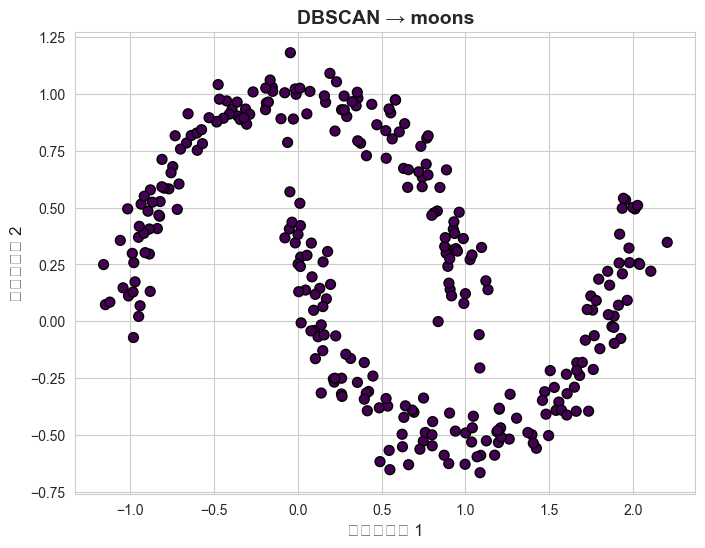

💡 উপরের কোডে my_algo, my_dataset, এবং প্যারামিটার পরিবর্তন করে দেখো কী হয়!


In [11]:
# 🎯 তুমি এখানে নিজে এক্সপেরিমেন্ট করো!

my_algo = 'DBSCAN'  # 'KMeans', 'Agglomerative', 'DBSCAN'
my_dataset = 'moons'  # 'blobs', 'moons', 'circles'
my_eps = 0.3  # DBSCAN-এর জন্য
my_k = 2  # K-Means এবং Agglomerative-এর জন্য

if my_dataset == 'blobs':
    X_d, y_d = X_blobs, y_blobs
elif my_dataset == 'moons':
    X_d, y_d = X_moons, y_moons
else:
    X_d, y_d = X_circles, y_circles

if my_algo == 'DBSCAN':
    model = DBSCAN(eps=my_eps, min_samples=5)
elif my_algo == 'KMeans':
    model = KMeans(n_clusters=my_k, random_state=42, n_init=10)
else:
    model = AgglomerativeClustering(n_clusters=my_k, linkage='ward')

y_pred = model.fit_predict(X_d)

plt.figure(figsize=(8, 6))
plt.scatter(X_d[:, 0], X_d[:, 1], c=y_pred, cmap='viridis', edgecolors='k', s=50)
plt.title(f'{my_algo} → {my_dataset}', fontsize=14, fontweight='bold')
plt.xlabel('ফিচার 1', fontsize=12)
plt.ylabel('ফিচার 2', fontsize=12)
plt.show()
print("💡 উপরের কোডে my_algo, my_dataset, এবং প্যারামিটার পরিবর্তন করে দেখো কী হয়!")

## 🌟 মজার তথ্য!

🎯 **Agglomerative Clustering**-কে **Hierarchical Clustering**-ও বলা হয়। এটি জীববিজ্ঞানে প্রজাতি শ্রেণীবদ্ধ করতে ব্যবহৃত হয়।

🎯 **DBSCAN** ১৯৯৬ সালে Martin Ester, Hans-Peter Kriegel, Jörg Sander এবং Xiaowei Xu তৈরি করেন। এটি Data Mining-এর সবচেয়ে গুরুত্বপূর্ণ অ্যালগরিদমগুলোর একটি!

🎯 **DBSCAN**-এর পুরো নাম: **D**ensity-**B**ased **S**patial **C**lustering of **A**pplications with **N**oise

🎯 **Agglomerative** শব্দটির অর্থ "একত্রিত হওয়া" — ল্যাটিন 'agglomerare' থেকে এসেছে।

🎯 ডেনড্রোগ্রাম শুধু ক্লাস্টারিং-এর জন্যই নয়, বংশতালিকা (family tree) তৈরিতেও ব্যবহৃত হয়!

## 🧠 তুমি কি বুঝতে পেরেছ?

❓ **প্রশ্ন ১**: Agglomerative ক্লাস্টারিং এবং K-Means-এর মধ্যে প্রধান পার্থক্য কী?

❓ **প্রশ্ন ২**: ডেনড্রোগ্রাম কীভাবে কাজ করে? উপরে থেকে নিচে না নিচে থেকে উপরে?

❓ **প্রশ্ন ৩**: DBSCAN-এ eps এবং min_samples কী নিয়ন্ত্রণ করে?

❓ **প্রশ্ন ৪**: কোন ধরনের ডেটার জন্য K-Meens ভালো, আর কোন ধরনের ডেটার জন্য DBSCAN ভালো?

❓ **প্রশ্ন ৫**: DBSCAN-এ আউটলায়ার চিহ্নিত করার সুবিধা কী?

---

**🧪 পরীক্ষা**: উপরের কোডে Circles ডেটাতে K-Means-এর n_clusters = 2 দিয়ে দেখো ফলাফল। এবার DBSCAN দিয়ে চেষ্টা করো।

---

**📝 মনে রেখো**:
- **Agglomerative**: bottom-up পদ্ধতি, ডেনড্রোগ্রাম তৈরি করে
- **DBSCAN**: ঘনত্ব-ভিত্তিক, আউটলায়ার চিহ্নিত করে, K-র মান বলার দরকার নেই
- **K-Means**: গোলাকার ক্লাস্টারের জন্য ভালো কিন্তু জটিল আকৃতির জন্য নয়
- **DBSCAN**: জটিল আকৃতির (মুন, সার্কেল) জন্য সেরা
- সব অ্যালগরিমেরই সুবিধা ও অসুবিধা আছে — সঠিক অ্যালগরিদম বেছে নেওয়াটাই গুরুত্বপূর্ণ

---

**🎉 অভিনন্দন!** তুমি Agglomerative এবং DBSCAN ক্লাস্টারিং শিখে ফেলেছো! এখন তুমি জানো কখন কোন ক্লাস্টারিং অ্যালগরিদম ব্যবহার করতে হবে। পরবর্তী পাঠে আমরা শিখব কিভাবে ক্লাস্টারিং-এর মান নির্ণয় করতে হয়।